In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
nav_df = pd.read_csv("../data/processed/02_nav_history_clean.csv")

print(nav_df.head())
print(nav_df.shape)

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
(46000, 3)


In [3]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

print(nav_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB
None


In [6]:
avg_nav = nav_df.groupby("date")["nav"].mean().reset_index()

fig = px.line(
    avg_nav,
    x="date",
    y="nav",
    title="Average Daily NAV Trend (2022-2026)"
)

fig.show()

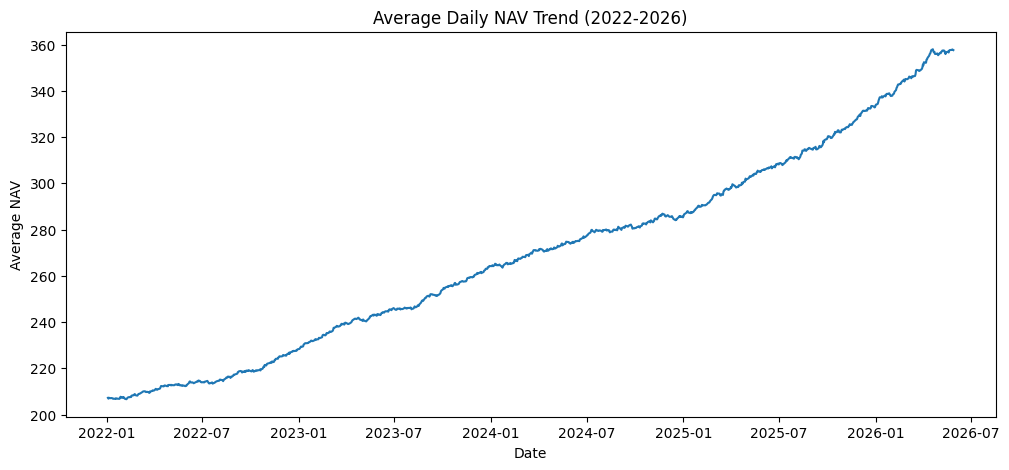

In [7]:
import matplotlib.pyplot as plt

avg_nav = nav_df.groupby("date")["nav"].mean()

plt.figure(figsize=(12,5))
plt.plot(avg_nav.index, avg_nav.values)
plt.title("Average Daily NAV Trend (2022-2026)")
plt.xlabel("Date")
plt.ylabel("Average NAV")
plt.show()

In [8]:
aum_df = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")

print(aum_df.head())
print(aum_df.columns)

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


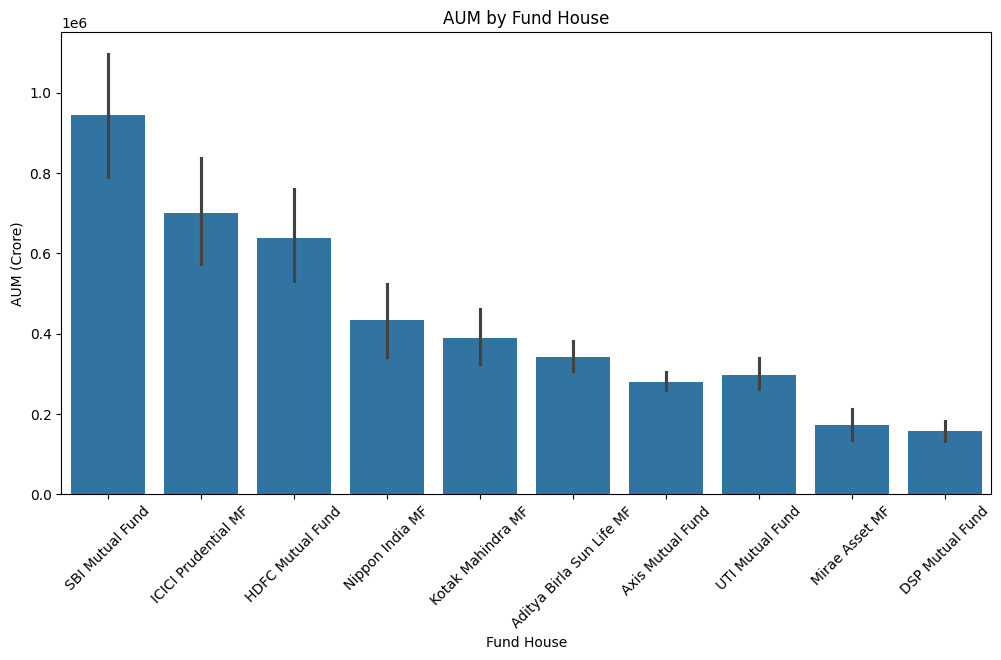

In [9]:
aum_df["date"] = pd.to_datetime(aum_df["date"])

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum_df,
    x="fund_house",
    y="aum_crore"
)

plt.title("AUM by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore)")
plt.xticks(rotation=45)

plt.show()

In [10]:
sip_df = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")

print(sip_df.head())
print(sip_df.columns)

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


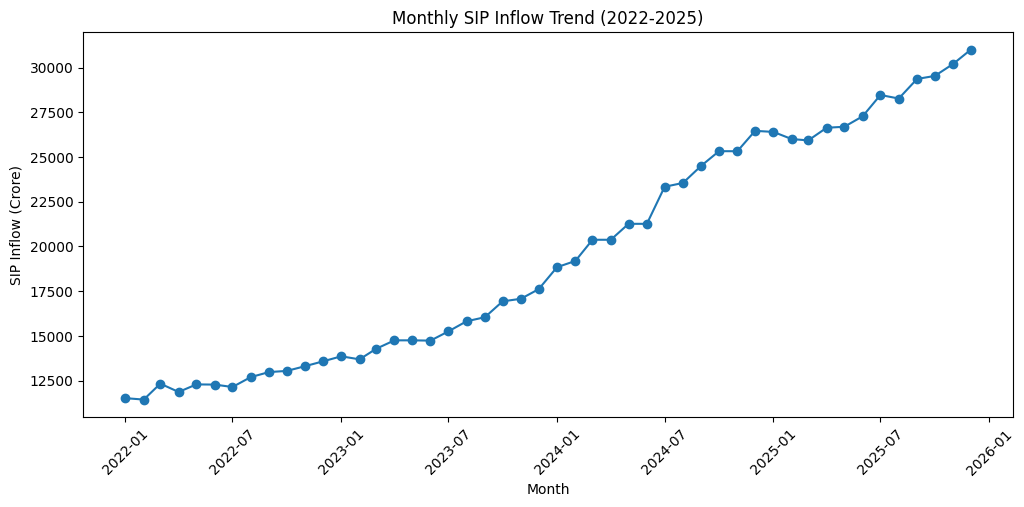

In [11]:
sip_df["month"] = pd.to_datetime(sip_df["month"])

plt.figure(figsize=(12,5))

plt.plot(
    sip_df["month"],
    sip_df["sip_inflow_crore"],
    marker="o"
)

plt.title("Monthly SIP Inflow Trend (2022-2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.xticks(rotation=45)

plt.show()

In [12]:
cat_df = pd.read_csv("../data/processed/05_category_inflows_clean.csv")

print(cat_df.head())
print(cat_df.columns)

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0
Index(['month', 'category', 'net_inflow_crore'], dtype='str')


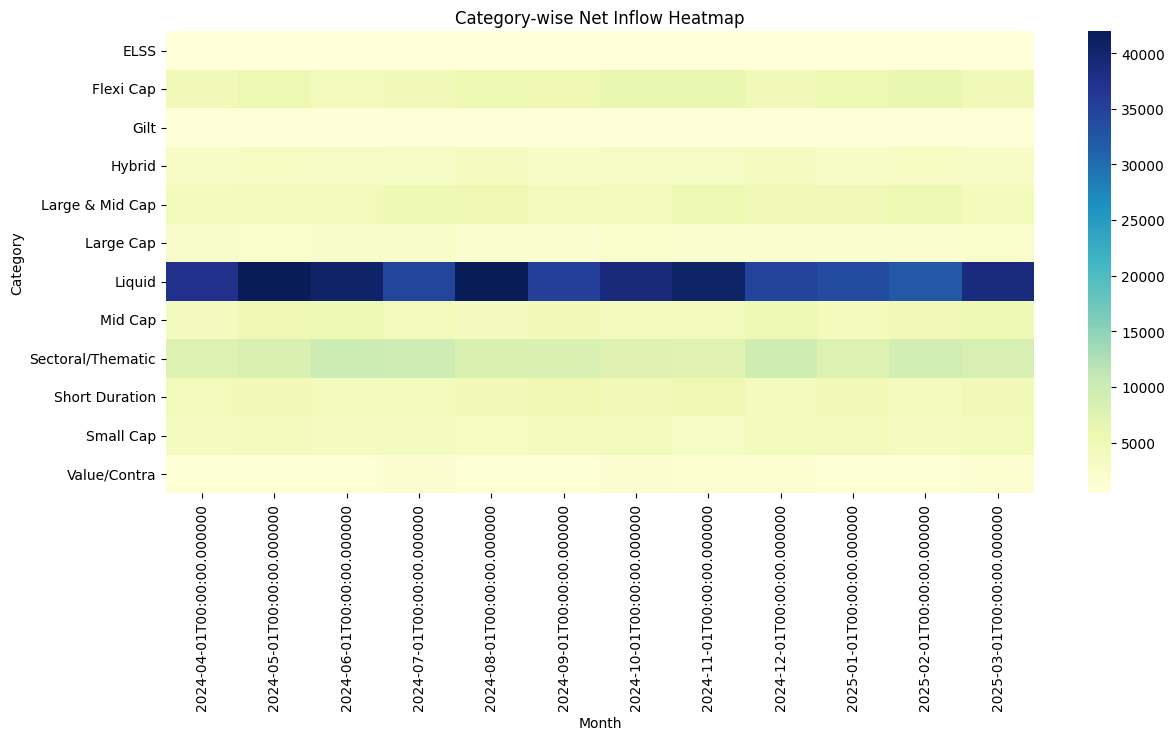

In [13]:
cat_df["month"] = pd.to_datetime(cat_df["month"])

heatmap_data = cat_df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.show()

In [14]:
investor_df = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

print(investor_df.head())
print(investor_df.columns)

  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verified  
2      M

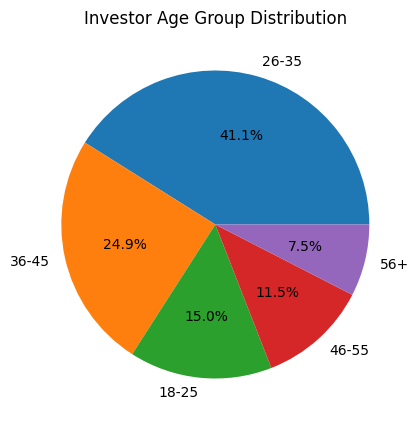

In [15]:
age_counts = investor_df["age_group"].value_counts()

plt.figure(figsize=(8,5))

age_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")

plt.show()


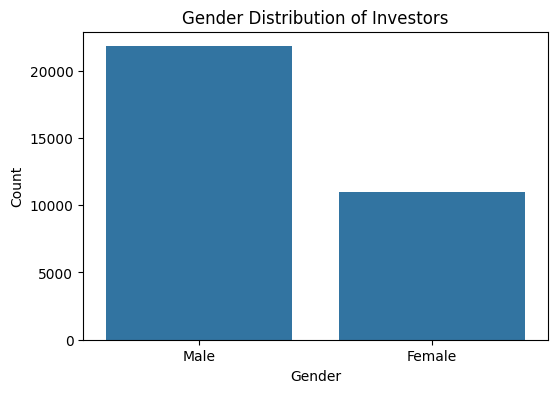

In [16]:
gender_counts = investor_df["gender"].value_counts()

plt.figure(figsize=(6,4))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title("Gender Distribution of Investors")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

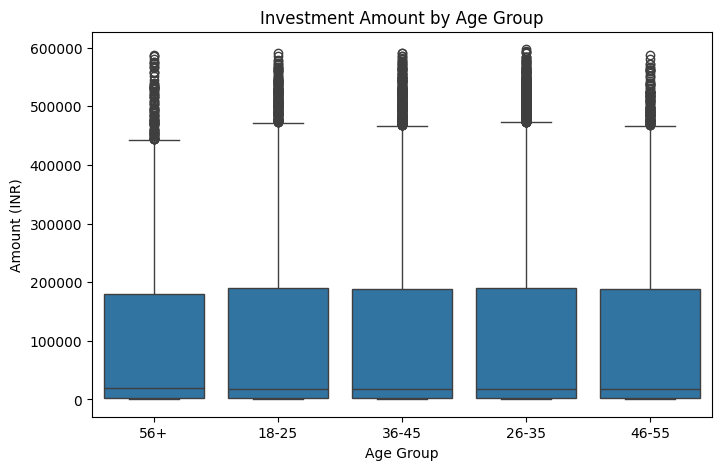

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="age_group",
    y="amount_inr",
    data=investor_df
)

plt.title("Investment Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")

plt.show()

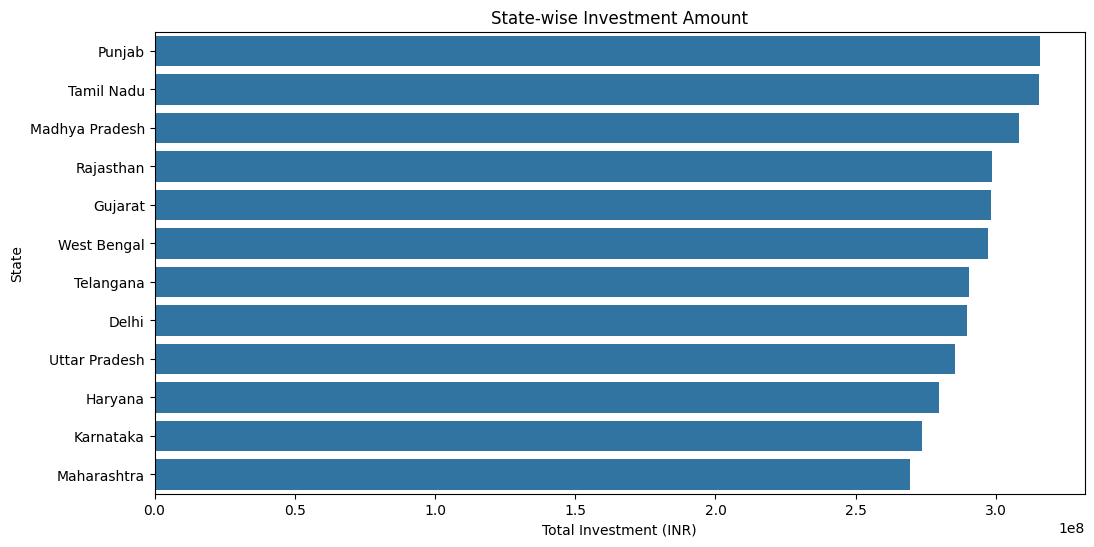

In [18]:
state_investment = investor_df.groupby("state")["amount_inr"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_investment.values,
    y=state_investment.index
)

plt.title("State-wise Investment Amount")
plt.xlabel("Total Investment (INR)")
plt.ylabel("State")

plt.show()

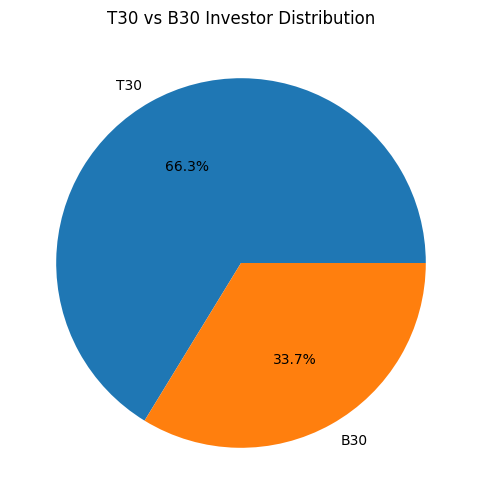

In [19]:
city_tier = investor_df["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    city_tier.values,
    labels=city_tier.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

In [20]:
folio_df = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")

print(folio_df.head())
print(folio_df.columns)

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


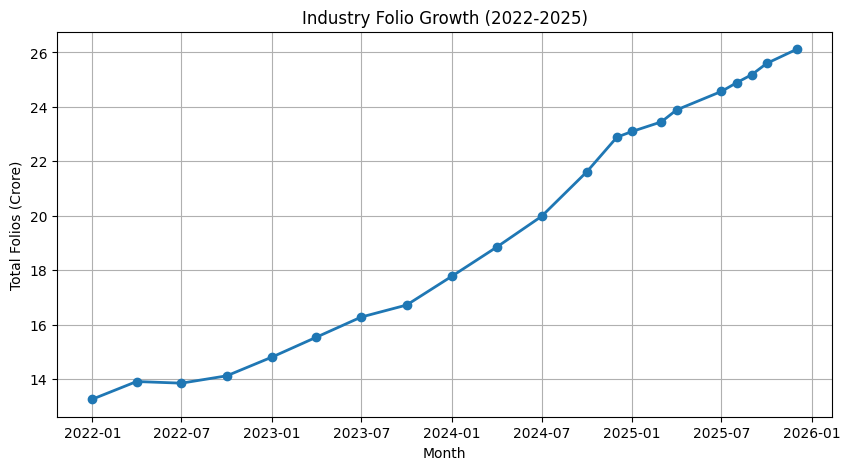

In [21]:
folio_df["month"] = pd.to_datetime(folio_df["month"])

plt.figure(figsize=(10,5))

plt.plot(
    folio_df["month"],
    folio_df["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Industry Folio Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)
plt.show()

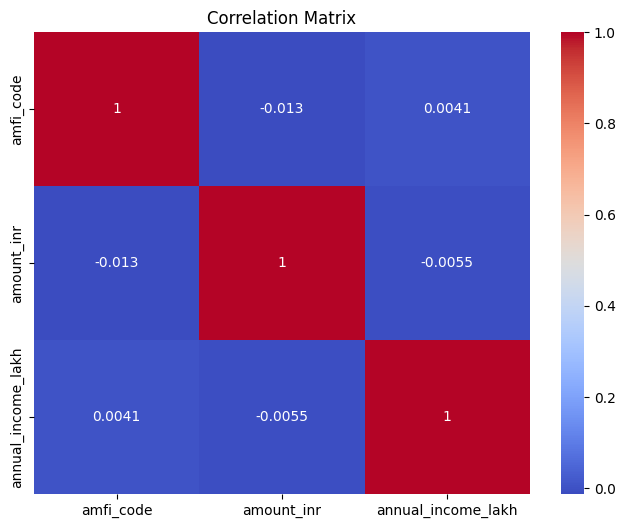

In [22]:
corr_data = investor_df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

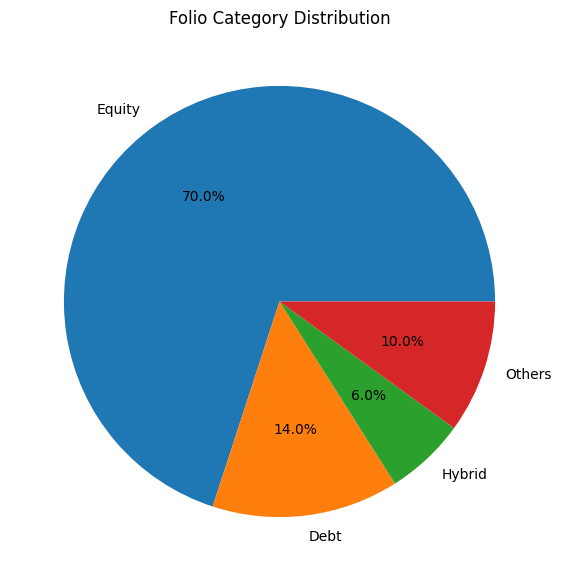

In [23]:
folio_latest = folio_df.iloc[-1]

labels = ["Equity", "Debt", "Hybrid", "Others"]

sizes = [
    folio_latest["equity_folios_crore"],
    folio_latest["debt_folios_crore"],
    folio_latest["hybrid_folios_crore"],
    folio_latest["others_folios_crore"]
]

plt.figure(figsize=(7,7))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%"
)

plt.title("Folio Category Distribution")
plt.show()